In [13]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
from vis_statistics import plot_cluster_statistics, plot_clusters_comparison
from vis_lc import get_lc_path, plot_cluster_lcs
from vis_periodogram import plot_cluster_periodograms, plot_cluster_periodograms_specific, plot_lsp_comparison

## Load master table

In [15]:
from astropy.table import Table

tbl = Table.read('master_table.fits')

scalar_cols = [name for name in tbl.colnames if len(tbl[name].shape) <= 1]
multi_cols  = [name for name in tbl.colnames if len(tbl[name].shape) >  1]

master_table = tbl[scalar_cols].to_pandas()

for col in multi_cols:
    master_table[col] = list(tbl[col])

print(master_table.shape)
master_table.head()

(868, 26)


,name,rms,std,MAD,sigmaG,skewness,von_neumann_ratio,J_Stetson,max_power,freq_at_max_power,...,SumLSP_7_4_Day_Power,SumLSP_4_1_Day_Power,SumLSP_1_p5_Day_Power,Entropy,sectors,cadence,n_sectors,LOC,AGE,FullPeriodogram
0,b'BMG32',0.061409,0.000668,0.000434,0.000639,0.397087,0.000783,0.935988,0.046111,0.36,...,0.206012,0.528081,0.173964,6.981934,[0],30.0,1,b'LMC',7.9,"[0.026436947727934403, 0.02746316684230981, 0...."
1,b'BMG32',0.161769,0.001006,0.000719,0.001065,-3.085452,0.001452,1.434224,0.174483,0.32,...,0.170952,1.841990,0.271482,6.934397,[1],30.0,1,b'LMC',7.9,"[0.002725964423310637, 0.007146544857656363, 0..."
2,b'BMG32',0.112893,0.001003,0.000626,0.000927,17.266732,0.001003,1.377425,0.174913,0.19,...,0.702348,1.005133,0.103512,7.047517,[2],30.0,1,b'LMC',7.9,"[0.05205991154852454, 0.07989218713552883, 0.0..."
3,b'BMG32',0.119027,0.001056,0.000722,0.001067,-2.638127,0.001146,1.451241,0.112790,0.37,...,0.451855,1.091927,0.113481,7.156956,[3],30.0,1,b'LMC',7.9,"[0.0703332776487653, 0.05668259486342891, 0.03..."
4,b'BMG32',0.061409,0.000850,0.000546,0.000811,-1.767441,0.000560,1.179916,0.068967,0.37,...,0.100536,0.647467,0.117497,7.651595,"[0, 1]",30.0,2,b'LMC',7.9,"[0.006778285831005086, 0.013017152060444029, 0..."


In [16]:
print(master_table.columns)

Index(['name', 'rms', 'std', 'MAD', 'sigmaG', 'skewness', 'von_neumann_ratio',
       'J_Stetson', 'max_power', 'freq_at_max_power', 'n_peaks',
       'ratio_of_power_at_high_v_low_freq', 'FAP', 'max_autocorrelation',
       'time_of_max_autocorrelation', 'SumLSP_10_7_Day_Power',
       'SumLSP_7_4_Day_Power', 'SumLSP_4_1_Day_Power', 'SumLSP_1_p5_Day_Power',
       'Entropy', 'sectors', 'cadence', 'n_sectors', 'LOC', 'AGE',
       'FullPeriodogram'],
      dtype='object')


In [17]:
new_table = master_table[['name', 'sectors', 'cadence', 'n_sectors', 'LOC', 'AGE']].copy()

In [18]:
new_table

,name,sectors,cadence,n_sectors,LOC,AGE
0,b'BMG32',[0],30.0,1,b'LMC',7.90
1,b'BMG32',[1],30.0,1,b'LMC',7.90
2,b'BMG32',[2],30.0,1,b'LMC',7.90
3,b'BMG32',[3],30.0,1,b'LMC',7.90
4,b'BMG32',"[0, 1]",30.0,2,b'LMC',7.90
...,...,...,...,...,...,...
863,b'SAURER 6',"[2, 3]",10.0,2,b'MW',9.20
864,b'SAURER 6',"[1, 2, 3]",10.0,3,b'MW',9.20
865,b'VDBERGH-HAGEN 92',[0],30.0,1,b'MW',8.91
866,b'VDBERGH-HAGEN 92',[1],30.0,1,b'MW',8.91


## Build updated table

In [19]:
from extract_LC_LSP import add_lightcurves, add_lsps
from invariant_summary_stats import add_variability_metrics
from invariant_LSP import add_invariant_LSP_stats

add_lightcurves(new_table)
add_lsps(new_table, P_min=0.1, P_max=10.0, alpha=5, fap_level=0.01)

[add_lightcurves] processing 868 rows across 55 clusters  |  cadence=30.0 min
[add_lightcurves] done  |  ok=868  missing=0  failed=0
[add_lsps] processing 868 rows  |  P=[0.1, 10.0] days  alpha=5  FAP=0.01  T_effective=True
[add_lsps] done  |  ok=868  skipped=0  failed=0


,name,sectors,cadence,n_sectors,LOC,AGE,LC_t,LC_x,LC_err_x,LSP_freq,LSP_power,LSP_FAP
0,b'BMG32',[0],30.0,1,b'LMC',7.90,"[1382.0534040342682, 1382.0742371425345, 1382....","[1.0000975450628886, 0.9998390715786509, 0.998...","[0.0006122919607540418, 0.0006073373966713103,...","[0.1, 0.10839170102580067, 0.11678340205160134...","[0.03138590632708135, 0.040288270937488116, 0....",0.025225
1,b'BMG32',[1],30.0,1,b'LMC',7.90,"[1410.9283805553364, 1410.9492137124166, 1411....","[0.9959518989804473, 0.9967784422446525, 0.998...","[0.0005083746925240335, 0.0005079584784039902,...","[0.1, 0.1090738263391421, 0.1181476526782842, ...","[0.000560826641981916, 0.0031543272050220434, ...",0.026706
2,b'BMG32',[2],30.0,1,b'LMC',7.90,"[1569.447644895273, 1569.468478380938, 1569.48...","[1.0013508768642108, 0.9995276507017979, 0.998...","[0.001107691177440487, 0.0011245434875321722, ...","[0.1, 0.1079403652130463, 0.1158807304260926, ...","[0.031273467477461146, 0.058572832576034586, 0...",0.023969
3,b'BMG32',[3],30.0,1,b'LMC',7.90,"[1653.948830404778, 1653.969663983743, 1653.99...","[1.000487143665834, 1.000670471719181, 1.00029...","[0.0004794438707843265, 0.0004792852712212794,...","[0.1, 0.10704321537201596, 0.1140864307440319,...","[0.08562990948547124, 0.09200512740769964, 0.0...",0.021693
4,b'BMG32',"[0, 1]",30.0,2,b'LMC',7.90,"[1382.0534040342682, 1382.0742371425345, 1382....","[1.0000975450628886, 0.9998390715786509, 0.998...","[0.0006122919607540418, 0.0006073373966713103,...","[0.1, 0.10435972165094515, 0.10871944330189029...","[0.0031286018190834317, 0.003848817359201781, ...",0.013784
...,...,...,...,...,...,...,...,...,...,...,...,...
863,b'SAURER 6',"[2, 3]",10.0,2,b'MW',9.20,"[2769.9167884451695, 2769.937622284224, 2769.9...","[0.9998862677333421, 0.999875633701568, 0.9997...","[4.274047492678074e-05, 4.273635535963352e-05,...","[0.1, 0.10426984111967216, 0.10853968223934432...","[0.0028019042016262643, 0.003643753164533522, ...",0.013278
864,b'SAURER 6',"[1, 2, 3]",10.0,3,b'MW',9.20,"[2420.0069345704387, 2420.027767841269, 2420.0...","[1.000409940549219, 0.9999722212505378, 1.0001...","[5.2359810627277134e-05, 5.2451677502881545e-0...","[0.1, 0.10276898072228992, 0.10553796144457982...","[0.0019369448212386287, 0.00294436948758637, 0...",0.009036
865,b'VDBERGH-HAGEN 92',[0],30.0,1,b'MW',8.91,"[1543.784412772034, 1543.80524656084, 1543.826...","[1.0003120573494295, 1.0006849320573654, 1.000...","[3.471778038086393e-05, 3.448285757645053e-05,...","[0.1, 0.1086174944495052, 0.1172349888990104, ...","[0.10587165306612822, 0.11418969050652931, 0.0...",0.025370
866,b'VDBERGH-HAGEN 92',[1],30.0,1,b'MW',8.91,"[1569.451349827374, 1569.472183108963, 1569.49...","[0.9999328665576012, 1.0000060038037917, 1.000...","[3.9436533405072194e-05, 4.0246802399471696e-0...","[0.1, 0.10794052408189338, 0.11588104816378675...","[0.10567532534874734, 0.1424068514684566, 0.12...",0.023970


In [20]:
# add_variability_metrics(new_table)
# add_invariant_LSP_stats(new_table)

# Compute Autocorrelation Fcn

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


def compute_acf_from_row(
    row,
    lag_bin_width=0.05,
    max_lag=20.0,
    min_pairs=20,
    use_errors=False,
):
    """
    Gap-aware lag-binned ACF for one pandas row.

    Expects:
        row["LC_t"]      = time array
        row["LC_x"]      = normalized flux array
        row["LC_err_x"]  = flux error array

    Returns:
        lags, acf, counts
    """

    t = np.asarray(row["LC_t"], dtype=float)
    x = np.asarray(row["LC_x"], dtype=float)
    err = np.asarray(row["LC_err_x"], dtype=float)

    mask = np.isfinite(t) & np.isfinite(x) & np.isfinite(err)
    t, x, err = t[mask], x[mask], err[mask]

    order = np.argsort(t)
    t, x, err = t[order], x[order], err[order]

    # mean-subtract and normalize
    x = x - np.nanmean(x)
    x = x / np.nanstd(x)

    lag_bins = np.arange(0, max_lag + lag_bin_width, lag_bin_width)
    lags = 0.5 * (lag_bins[:-1] + lag_bins[1:])

    acf_sum = np.zeros(len(lags))
    weight_sum = np.zeros(len(lags))
    counts = np.zeros(len(lags), dtype=int)

    n = len(t)

    for i in range(n - 1):
        dt = t[i+1:] - t[i]

        keep = dt <= max_lag
        if not np.any(keep):
            continue

        dt = dt[keep]
        xj = x[i+1:][keep]

        prod = x[i] * xj

        if use_errors:
            ej = err[i+1:][keep]
            weights = 1.0 / (err[i]**2 + ej**2)
        else:
            weights = np.ones_like(prod)

        bin_idx = np.searchsorted(lag_bins, dt, side="right") - 1

        valid = (bin_idx >= 0) & (bin_idx < len(lags))
        bin_idx = bin_idx[valid]
        prod = prod[valid]
        weights = weights[valid]

        acf_sum += np.bincount(
            bin_idx,
            weights=prod * weights,
            minlength=len(lags)
        )

        weight_sum += np.bincount(
            bin_idx,
            weights=weights,
            minlength=len(lags)
        )

        counts += np.bincount(
            bin_idx,
            minlength=len(lags)
        )

    acf = acf_sum / weight_sum
    acf[counts < min_pairs] = np.nan

    return lags, acf, counts

In [30]:
import numpy as np
from scipy.signal import find_peaks, peak_widths


def summarize_acf_from_row(
    row,
    lag_bin_width=0.05,
    max_lag=20.0,
    min_pairs=50,
    use_errors=False,
    min_peak_lag=0.1,
    min_peak_prominence=0.05,
):
    """
    Computes gap-aware ACF summary statistics for one pandas row.

    Requires compute_acf_from_row() from above.

    Returns a dict of ACF features.
    """

    lags, acf, counts = compute_acf_from_row(
        row,
        lag_bin_width=lag_bin_width,
        max_lag=max_lag,
        min_pairs=min_pairs,
        use_errors=use_errors,
    )

    finite = np.isfinite(acf)

    # ---------- peaks ----------
    peak_mask = finite & (lags > min_peak_lag)

    peaks, props = find_peaks(
        acf[peak_mask],
        prominence=min_peak_prominence,
    )

    valid_lags = lags[peak_mask]
    valid_acf = acf[peak_mask]

    if len(peaks) > 0:
        peak_lags = valid_lags[peaks]
        peak_heights = valid_acf[peaks]
        peak_proms = props["prominences"]

        # strongest positive ACF peak
        best = np.argmax(peak_heights)

        acf_period = peak_lags[best]
        acf_peak_height = peak_heights[best]
        acf_peak_prominence = peak_proms[best]

        widths = peak_widths(valid_acf, peaks, rel_height=0.5)[0]
        acf_peak_width_days = widths[best] * lag_bin_width

        n_acf_peaks = len(peaks)

        if len(peak_lags) > 1:
            peak_spacing = np.diff(peak_lags)
            acf_peak_spacing_mean = np.nanmean(peak_spacing)
            acf_peak_spacing_std = np.nanstd(peak_spacing)
        else:
            acf_peak_spacing_mean = np.nan
            acf_peak_spacing_std = np.nan

        first_peak_lag = peak_lags[0]
        first_peak_height = peak_heights[0]

    else:
        acf_period = np.nan
        acf_peak_height = np.nan
        acf_peak_prominence = np.nan
        acf_peak_width_days = np.nan
        n_acf_peaks = 0
        acf_peak_spacing_mean = np.nan
        acf_peak_spacing_std = np.nan
        first_peak_lag = np.nan
        first_peak_height = np.nan

    # ---------- coherence time ----------
    # first lag where abs(ACF) falls below 1/e
    finite_nonzero = finite & (lags > 0)

    below = np.where(finite_nonzero & (np.abs(acf) < 1 / np.e))[0]

    if len(below) > 0:
        acf_tau_coh = lags[below[0]]
    else:
        acf_tau_coh = np.nan

    if np.isfinite(acf_tau_coh) and np.isfinite(acf_period) and acf_period > 0:
        acf_coherence_cycles = acf_tau_coh / acf_period
    else:
        acf_coherence_cycles = np.nan

    # ---------- global ACF shape ----------
    if np.any(finite):
        acf_abs_area = np.trapz(np.abs(acf[finite]), lags[finite])
        acf_signed_area = np.trapz(acf[finite], lags[finite])
        acf_rms = np.sqrt(np.nanmean(acf[finite]**2))
        acf_max = np.nanmax(acf[finite & (lags > min_peak_lag)])
        acf_min = np.nanmin(acf[finite & (lags > min_peak_lag)])
    else:
        acf_abs_area = np.nan
        acf_signed_area = np.nan
        acf_rms = np.nan
        acf_max = np.nan
        acf_min = np.nan

    # ---------- reliability / pair-count info ----------
    valid_counts = counts[np.isfinite(acf)]

    if len(valid_counts) > 0:
        median_pair_count = np.nanmedian(valid_counts)
        min_pair_count = np.nanmin(valid_counts)
    else:
        median_pair_count = np.nan
        min_pair_count = np.nan

    return {
        # main period/coherence features
        "acf_period": acf_period,
        "acf_tau_coh": acf_tau_coh,
        "acf_coherence_cycles": acf_coherence_cycles,

        # strongest peak features
        "acf_peak_height": acf_peak_height,
        "acf_peak_prominence": acf_peak_prominence,
        "acf_peak_width_days": acf_peak_width_days,

        # first peak features
        "acf_first_peak_lag": first_peak_lag,
        "acf_first_peak_height": first_peak_height,

        # multi-peak structure
        "acf_n_peaks": n_acf_peaks,
        "acf_peak_spacing_mean": acf_peak_spacing_mean,
        "acf_peak_spacing_std": acf_peak_spacing_std,

        # global shape
        "acf_abs_area": acf_abs_area,
        "acf_signed_area": acf_signed_area,
        "acf_rms": acf_rms,
        "acf_max": acf_max,
        "acf_min": acf_min,

        # reliability
        "acf_median_pair_count": median_pair_count,
        "acf_min_pair_count": min_pair_count,
    }

In [31]:
def plot_acf_from_row(
    row,
    lag_bin_width=0.05,
    max_lag=20.0,
    min_pairs=20,
    use_errors=False,
    show_counts=True,
    find_acf_peaks=True,
    min_peak_lag=0.1,
    min_peak_prominence=0.05,
):
    """
    Computes and plots gap-aware ACF for one pandas row.
    """

    lags, acf, counts = compute_acf_from_row(
        row,
        lag_bin_width=lag_bin_width,
        max_lag=max_lag,
        min_pairs=min_pairs,
        use_errors=use_errors,
    )

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(lags, acf, lw=1.5)
    ax.axhline(0, color="k", lw=1, alpha=0.5)

    ax.set_xlabel("Lag [days]")
    ax.set_ylabel("ACF")
    ax.set_title(f"ACF: {row['name']} | sectors={row['sectors']}")

    peak_lags = np.array([])
    peak_vals = np.array([])

    if find_acf_peaks:
        valid = np.isfinite(acf) & (lags > min_peak_lag)

        peaks, props = find_peaks(
            acf[valid],
            prominence=min_peak_prominence
        )

        valid_lags = lags[valid]
        valid_acf = acf[valid]

        peak_lags = valid_lags[peaks]
        peak_vals = valid_acf[peaks]

        ax.scatter(peak_lags, peak_vals, zorder=5)

    if show_counts:
        ax2 = ax.twinx()
        ax2.plot(lags, counts, alpha=0.25)
        ax2.set_ylabel("Pair counts")

    plt.tight_layout()
    plt.show()

    return lags, acf, counts, peak_lags, peak_vals

In [32]:
summarize_acf_from_row(
    new_table.iloc[1],
    lag_bin_width=0.05,
    max_lag=20,
    min_pairs=50,
)


{'acf_period': 15.775,
 'acf_tau_coh': 0.275,
 'acf_coherence_cycles': 0.017432646592709985,
 'acf_peak_height': 0.482217900954348,
 'acf_peak_prominence': 0.8013715749728848,
 'acf_peak_width_days': 1.36274532389468,
 'acf_first_peak_lag': 2.7750000000000004,
 'acf_first_peak_height': 0.2473447726472494,
 'acf_n_peaks': 10,
 'acf_peak_spacing_mean': 1.7777777777777777,
 'acf_peak_spacing_std': 0.8290259046720335,
 'acf_abs_area': 3.0971339019557407,
 'acf_signed_area': -0.017219455879005918,
 'acf_rms': 0.20252261753313514,
 'acf_max': 0.5482288389195851,
 'acf_min': -0.46235371536424846,
 'acf_median_pair_count': 1083.5,
 'acf_min_pair_count': 549}

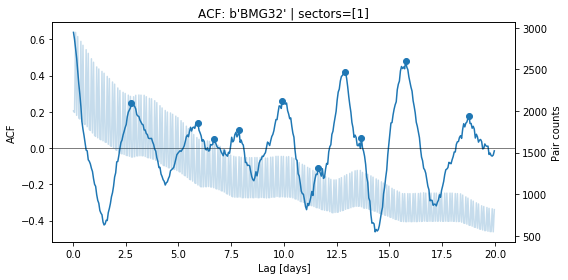

(array([ 0.025,  0.075,  0.125,  0.175,  0.225,  0.275,  0.325,  0.375,
         0.425,  0.475,  0.525,  0.575,  0.625,  0.675,  0.725,  0.775,
         0.825,  0.875,  0.925,  0.975,  1.025,  1.075,  1.125,  1.175,
         1.225,  1.275,  1.325,  1.375,  1.425,  1.475,  1.525,  1.575,
         1.625,  1.675,  1.725,  1.775,  1.825,  1.875,  1.925,  1.975,
         2.025,  2.075,  2.125,  2.175,  2.225,  2.275,  2.325,  2.375,
         2.425,  2.475,  2.525,  2.575,  2.625,  2.675,  2.725,  2.775,
         2.825,  2.875,  2.925,  2.975,  3.025,  3.075,  3.125,  3.175,
         3.225,  3.275,  3.325,  3.375,  3.425,  3.475,  3.525,  3.575,
         3.625,  3.675,  3.725,  3.775,  3.825,  3.875,  3.925,  3.975,
         4.025,  4.075,  4.125,  4.175,  4.225,  4.275,  4.325,  4.375,
         4.425,  4.475,  4.525,  4.575,  4.625,  4.675,  4.725,  4.775,
         4.825,  4.875,  4.925,  4.975,  5.025,  5.075,  5.125,  5.175,
         5.225,  5.275,  5.325,  5.375,  5.425,  5.475,  5.525, 

In [28]:
plot_acf_from_row(
    new_table.iloc[1],
    lag_bin_width = 0.05,   # days ≈ 72 minutes
    #max_lag=20.0,
    #min_pairs=20,
    #use_errors=False,
    #show_counts=True,
    #find_acf_peaks=True,
    #min_peak_lag=0.1,
    #min_peak_prominence=0.05,
)


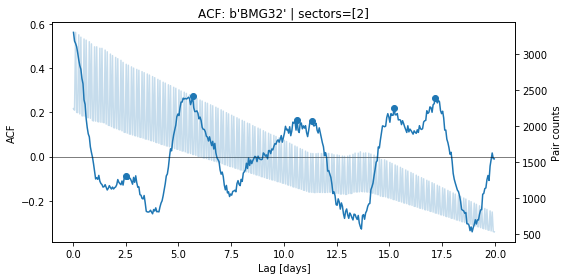

(array([ 0.025,  0.075,  0.125,  0.175,  0.225,  0.275,  0.325,  0.375,
         0.425,  0.475,  0.525,  0.575,  0.625,  0.675,  0.725,  0.775,
         0.825,  0.875,  0.925,  0.975,  1.025,  1.075,  1.125,  1.175,
         1.225,  1.275,  1.325,  1.375,  1.425,  1.475,  1.525,  1.575,
         1.625,  1.675,  1.725,  1.775,  1.825,  1.875,  1.925,  1.975,
         2.025,  2.075,  2.125,  2.175,  2.225,  2.275,  2.325,  2.375,
         2.425,  2.475,  2.525,  2.575,  2.625,  2.675,  2.725,  2.775,
         2.825,  2.875,  2.925,  2.975,  3.025,  3.075,  3.125,  3.175,
         3.225,  3.275,  3.325,  3.375,  3.425,  3.475,  3.525,  3.575,
         3.625,  3.675,  3.725,  3.775,  3.825,  3.875,  3.925,  3.975,
         4.025,  4.075,  4.125,  4.175,  4.225,  4.275,  4.325,  4.375,
         4.425,  4.475,  4.525,  4.575,  4.625,  4.675,  4.725,  4.775,
         4.825,  4.875,  4.925,  4.975,  5.025,  5.075,  5.125,  5.175,
         5.225,  5.275,  5.325,  5.375,  5.425,  5.475,  5.525, 

In [33]:
plot_acf_from_row(
    new_table.iloc[2],
    lag_bin_width = 0.05,   # days ≈ 72 minutes
    #max_lag=20.0,
    #min_pairs=20,
    #use_errors=False,
    #show_counts=True,
    #find_acf_peaks=True,
    #min_peak_lag=0.1,
    #min_peak_prominence=0.05,
)


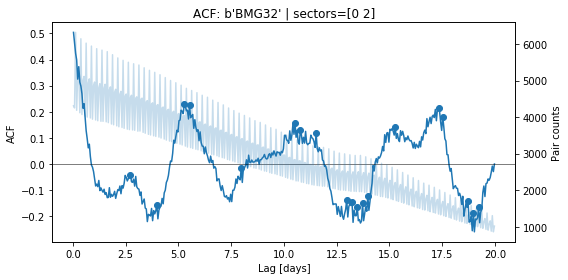

(array([ 0.025,  0.075,  0.125,  0.175,  0.225,  0.275,  0.325,  0.375,
         0.425,  0.475,  0.525,  0.575,  0.625,  0.675,  0.725,  0.775,
         0.825,  0.875,  0.925,  0.975,  1.025,  1.075,  1.125,  1.175,
         1.225,  1.275,  1.325,  1.375,  1.425,  1.475,  1.525,  1.575,
         1.625,  1.675,  1.725,  1.775,  1.825,  1.875,  1.925,  1.975,
         2.025,  2.075,  2.125,  2.175,  2.225,  2.275,  2.325,  2.375,
         2.425,  2.475,  2.525,  2.575,  2.625,  2.675,  2.725,  2.775,
         2.825,  2.875,  2.925,  2.975,  3.025,  3.075,  3.125,  3.175,
         3.225,  3.275,  3.325,  3.375,  3.425,  3.475,  3.525,  3.575,
         3.625,  3.675,  3.725,  3.775,  3.825,  3.875,  3.925,  3.975,
         4.025,  4.075,  4.125,  4.175,  4.225,  4.275,  4.325,  4.375,
         4.425,  4.475,  4.525,  4.575,  4.625,  4.675,  4.725,  4.775,
         4.825,  4.875,  4.925,  4.975,  5.025,  5.075,  5.125,  5.175,
         5.225,  5.275,  5.325,  5.375,  5.425,  5.475,  5.525, 

In [34]:
plot_acf_from_row(
    new_table.iloc[5],
    lag_bin_width = 0.05,   # days ≈ 72 minutes
    #max_lag=20.0,
    #min_pairs=20,
    #use_errors=False,
    #show_counts=True,
    #find_acf_peaks=True,
    #min_peak_lag=0.1,
    #min_peak_prominence=0.05,
)


In [27]:
new_table.iloc[1]

name                                                  b'BMG32'
sectors                                                    [1]
cadence                                                     30
n_sectors                                                    1
LOC                                                     b'LMC'
AGE                                                        7.9
LC_t         [1410.9283805553364, 1410.9492137124166, 1411....
LC_x         [0.9959518989804473, 0.9967784422446525, 0.998...
LC_err_x     [0.0005083746925240335, 0.0005079584784039902,...
LSP_freq     [0.1, 0.1090738263391421, 0.1181476526782842, ...
LSP_power    [0.000560826641981916, 0.0031543272050220434, ...
LSP_FAP                                              0.0267064
Name: 1, dtype: object